# Reconstruct images with an AutoEncoder (AE)

In [22]:
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.datasets as datasets
from torchvision.transforms import ToTensor

## Import the data

In [101]:
mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=ToTensor())
mnist_test = datasets.MNIST(root="./test", train=False, download=True, transform=ToTensor())

## Visualize the data

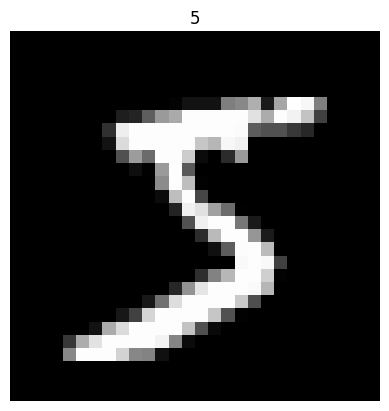

In [104]:
image, label = mnist_train[0]

plt.figure()
plt.imshow(image.squeeze(), cmap = 'gray')
plt.title(label)
plt.axis('off')
plt.show()

In [59]:
image.shape

torch.Size([1, 28, 28])

That makes up to $ 28*28 = 784 $ values.

## Create the dataloader

In [60]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(mnist_train, batch_size=256, shuffle=True)
test_dataloader = DataLoader(mnist_test, batch_size=256, shuffle=True)

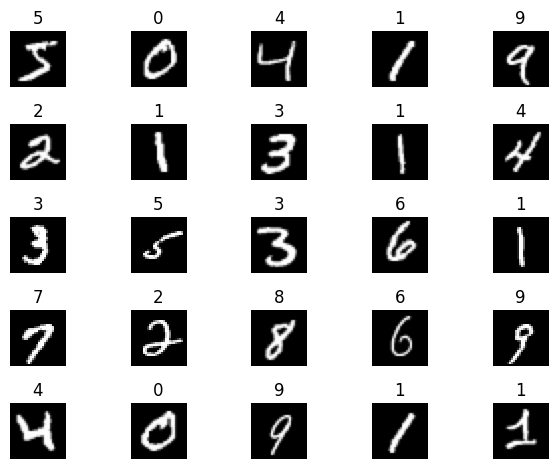

In [61]:
import numpy as np

random_samples = np.random.randint(1, len(mnist_train), (25))

for idx in range(random_samples.shape[0]):
    plt.subplot(5, 5, idx+1)
    plt.imshow(mnist_train[idx][0][0].numpy(), cmap='gray')
    plt.title(mnist_train[idx][1])
    plt.axis('off')

plt.tight_layout()
plt.show()

## Build the model(s)

In [74]:
class DeepAutoencoder(torch.nn.Module):
    def __init__(self):
        super().__init__()        
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(28 * 28, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 10)
        )
          
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(10, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, 28 * 28),
            torch.nn.Sigmoid()
        )
  
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [75]:
model = DeepAutoencoder()
print(model)

DeepAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=784, bias=True)
    (7): Sigmoid()
  )
)


## Training loop

In [76]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [77]:
EPOCHS = 20

train_loss = []

# Dictionary that will store the different images and outputs for various epochs
outputs = {}

BATCH_SIZE = len(train_dataloader)

for epoch in range(EPOCHS):
    
    running_loss = 0
    
    for batch in train_dataloader:
        inputs, _ = batch
        inputs = inputs.reshape(-1, 28*28)
        
        # Forward pass in the autoencoder
        output = model(inputs)
        # Loss
        loss = criterion(output, inputs)
        # Loss backward
        optimizer.zero_grad()
        loss.backward()
        # Optimizer step
        optimizer.step()

        # Incrementing loss
        running_loss += loss.item()
    
    running_loss /= BATCH_SIZE
    train_loss.append(running_loss)
    # Print loss
    # if ...
    print(f"Epoch: {epoch} - loss: {running_loss}")

    outputs[epoch+1] = {'img': inputs, 'out': output}

Epoch: 0 - loss: 0.07243385313356177
Epoch: 1 - loss: 0.04767469841432064
Epoch: 2 - loss: 0.03623901529515043
Epoch: 3 - loss: 0.029230192248174483
Epoch: 4 - loss: 0.02575741950026218
Epoch: 5 - loss: 0.023830452632713824
Epoch: 6 - loss: 0.02253198427881332
Epoch: 7 - loss: 0.0214632400331345
Epoch: 8 - loss: 0.02047689213873224
Epoch: 9 - loss: 0.01966751087060634
Epoch: 10 - loss: 0.0188874066985668
Epoch: 11 - loss: 0.01808690496106097
Epoch: 12 - loss: 0.017516122480973284
Epoch: 13 - loss: 0.017072863226875346
Epoch: 14 - loss: 0.01674120374658006
Epoch: 15 - loss: 0.016431882886334938
Epoch: 16 - loss: 0.016164136563051254
Epoch: 17 - loss: 0.015936342305801016
Epoch: 18 - loss: 0.015706354034866424
Epoch: 19 - loss: 0.015506591727124883


## Visualize training

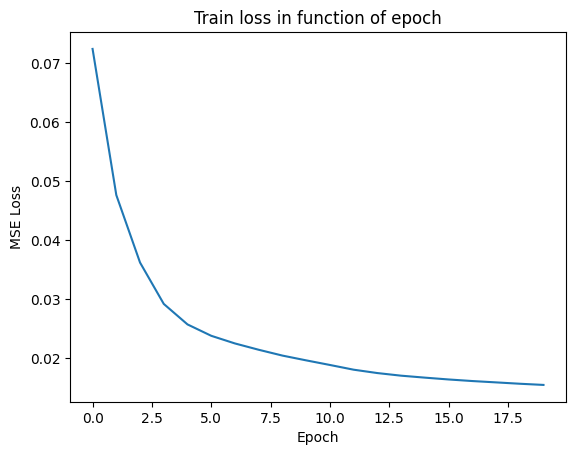

In [78]:
plt.figure()
plt.plot(range(EPOCHS), train_loss)
plt.title("Train loss in function of epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

## Visualize the results

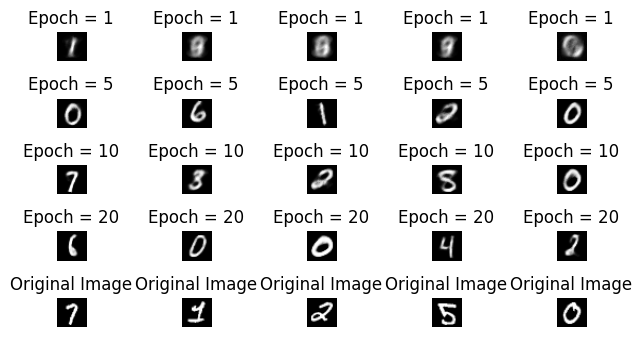

In [94]:
# Plotting is done on a 7x5 subplot
# Plotting the reconstructed images
  
# Initializing subplot counter
counter = 1
  
# Plotting reconstructions
# for epochs = [1, 5, 10, 50, 100]
epochs_list = [1, 5, 10, 20]
  
# Iterating over specified epochs
for val in epochs_list:
    
      # Extracting recorded information
    temp = outputs[val]['out'].detach().numpy()
    title_text = f"Epoch = {val}"
      
    # Plotting first five images of the last batch
    for idx in range(5):
        plt.subplot(7, 5, counter)
        plt.title(title_text)
        plt.imshow(temp[idx].reshape(28,28), cmap= 'gray')
        plt.axis('off')
          
        # Incrementing the subplot counter
        counter+=1
  
# Plotting original images
  
# Iterating over first five
# images of the last batch
for idx in range(5):
      
    # Obtaining image from the dictionary
    val = outputs[10]['img']
      
    # Plotting image
    plt.subplot(7,5,counter)
    plt.imshow(val[idx].reshape(28, 28), cmap = 'gray')
    plt.title("Original Image")
    plt.axis('off')
      
    # Incrementing subplot counter
    counter+=1
  
plt.tight_layout()
plt.show()

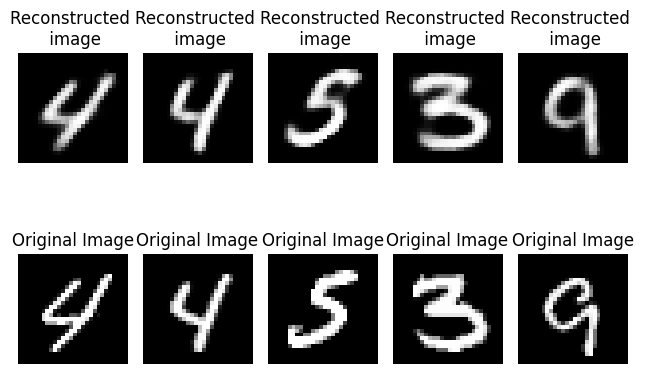

In [100]:
# Dictionary that will store the different
# images and outputs for various epochs
outputs = {}
  
# Extracting the last batch from the test 
# dataset
img, _ = list(test_dataloader)[-1]
  
# Reshaping into 1d vector
img = img.reshape(-1, 28 * 28)
  
# Generating output for the obtained
# batch
out = model(img)
  
# Storing information in dictionary
outputs['img'] = img
outputs['out'] = out
  
# Plotting reconstructed images
# Initializing subplot counter
counter = 1
val = outputs['out'].detach().numpy()
  
# Plotting first 10 images of the batch
for idx in range(5):
    plt.subplot(2, 5, counter)
    plt.title("Reconstructed \n image")
    plt.imshow(val[idx].reshape(28, 28), cmap='gray')
    plt.axis('off')
  
    # Incrementing subplot counter
    counter += 1
  
# Plotting original images
  
# Plotting first 10 images
for idx in range(5):
    val = outputs['img']
    plt.subplot(2, 5, counter)
    plt.imshow(val[idx].reshape(28, 28), cmap='gray')
    plt.title("Original Image")
    plt.axis('off')
  
    # Incrementing subplot counter
    counter += 1
  
plt.tight_layout()
plt.show()